# Gaming Analytics: Player Retention & Engagement

## 1. Comprensión inicial de los datos

### Objetivo

En esta etapa se realizará una revisión inicial de los datos disponibles para comprender su estructura, contenido y calidad antes de realizar cualquier transformación o análisis.

Se revisarán:

- La estructura de cada conjunto de datos.
- El número de registros y variables.
- Los tipos de datos.
- Los valores faltantes.
- Los registros duplicados.
- Los valores únicos y rangos de las variables.
- Las variables relacionadas con registro, actividad de los jugadores y experimento A/B.

Esta revisión permitirá determinar qué preguntas de negocio pueden responderse con los datos disponibles y definir posteriormente la estrategia de limpieza y análisis.

In [1]:
import pandas as pd

import matplotlib.pyplot as plt

from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import ttest_ind


## 2. Carga de los datos

Se cargarán los tres conjuntos de datos proporcionados para el proyecto:
- Datos de registro de usuarios.
- Datos de actividad/autenticación.
- Datos del experimento A/B.

In [ ]:
reg_data = pd.read_csv("../raw/reg_data.csv", sep=";")
auth_data = pd.read_csv("../raw/auth_data.csv", sep=";")
ab_test = pd.read_csv("../raw/ab_test.csv", sep=";")

: 

## 3. Exploración inicial de los datos

En esta etapa se revisará la estructura y el contenido de los tres conjuntos de datos para comprender qué información contienen y cómo se relacionan entre sí.

Se analizarán sus dimensiones, nombres y tipos de variables, así como una muestra de los registros disponibles. Esta revisión permitirá identificar las características principales de los datos antes de realizar cualquier transformación.

In [ ]:
print("reg_data:", reg_data.shape)
print("auth_data:", auth_data.shape)
print("ab_test:", ab_test.shape)

reg_data: (1000000, 2)
auth_data: (9601013, 2)
ab_test: (404770, 3)


: 

In [ ]:
display(reg_data.head())
display(auth_data.head())
display(ab_test.head())

,reg_ts,uid
0,911382223,1
1,932683089,2
2,947802447,3
3,959523541,4
4,969103313,5


,auth_ts,uid
0,911382223,1
1,932683089,2
2,932921206,2
3,933393015,2
4,933875379,2


,user_id,revenue,testgroup
0,1,0,b
1,2,0,a
2,3,0,a
3,4,0,b
4,5,0,b


: 

In [ ]:
reg_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 2 columns):
 #   Column  Non-Null Count    Dtype
---  ------  --------------    -----
 0   reg_ts  1000000 non-null  int64
 1   uid     1000000 non-null  int64
dtypes: int64(2)
memory usage: 15.3 MB


: 

In [ ]:
auth_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9601013 entries, 0 to 9601012
Data columns (total 2 columns):
 #   Column   Dtype
---  ------   -----
 0   auth_ts  int64
 1   uid      int64
dtypes: int64(2)
memory usage: 146.5 MB


: 

In [ ]:
ab_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404770 entries, 0 to 404769
Data columns (total 3 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   user_id    404770 non-null  int64 
 1   revenue    404770 non-null  int64 
 2   testgroup  404770 non-null  object
dtypes: int64(2), object(1)
memory usage: 9.3+ MB


: 


## 4. Revisión de calidad de los datos

Antes de realizar transformaciones, se revisará la existencia de registros duplicados y confirmaremos valores faltantes.

Los duplicados se evaluarán inicialmente como registros completos. No se eliminarán registros únicamente porque compartan el mismo identificador de usuario, ya que un usuario puede tener múltiples eventos de actividad.

In [ ]:
print("Duplicados en reg_data:", reg_data.duplicated().sum())
print("Duplicados en auth_data:", auth_data.duplicated().sum())
print("Duplicados en ab_test:", ab_test.duplicated().sum())

Duplicados en reg_data: 0
Duplicados en auth_data: 0
Duplicados en ab_test: 0


: 

In [ ]:
print("Valores nulos en reg_data:")
print(reg_data.isna().sum())

print("\nValores nulos en auth_data:")
print(auth_data.isna().sum())

print("\nValores nulos en ab_test:")
print(ab_test.isna().sum())

Valores nulos en reg_data:
reg_ts    0
uid       0
dtype: int64

Valores nulos en auth_data:
auth_ts    0
uid        0
dtype: int64

Valores nulos en ab_test:
user_id      0
revenue      0
testgroup    0
dtype: int64


: 

Con esto podemos concluir que no tenemos duplicados ni valores nulos en ninguno de los datasets.

## 5. Análisis preliminar de las fechas

Las variables `reg_ts` y `auth_ts` contienen marcas de tiempo almacenadas como valores enteros. Antes de convertirlas a un formato de fecha legible, se revisará su rango para conocer el periodo cubierto por los datos.

In [ ]:
print("Rango de reg_ts:")
print(reg_data["reg_ts"].min(), "→", reg_data["reg_ts"].max())

print("\nRango de auth_ts:")
print(auth_data["auth_ts"].min(), "→", auth_data["auth_ts"].max())

Rango de reg_ts:
911382223 → 1600874244

Rango de auth_ts:
911382223 → 1600874244


: 

Ambos datasets cubren el mismo rango temporal, lo que permite relacionar los registros de usuarios con su actividad posterior durante el periodo disponible.

### Preparación de las fechas

Las variables `reg_ts` y `auth_ts` están almacenadas como timestamps Unix. Se convertirán a formato datetime para poder calcular la diferencia entre la fecha de registro y las fechas posteriores de actividad de cada usuario.

In [ ]:
reg_data["reg_date"] = pd.to_datetime(reg_data["reg_ts"], unit="s")
auth_data["auth_date"] = pd.to_datetime(auth_data["auth_ts"], unit="s")

# Normalizar las fechas para obtener solo la parte de la fecha (sin tiempo)
reg_data["reg_day"] = reg_data["reg_date"].dt.normalize()
auth_data["auth_day"] = auth_data["auth_date"].dt.normalize()

: 

### Retención global D1, D7, D14 y D30

In [ ]:
def calculate_retention(reg_df, auth_df, retention_days=(1, 7, 14, 30)):
    # Preparar datos
    reg = reg_df[["uid", "reg_ts"]].copy()
    auth = auth_df[["uid", "auth_ts"]].copy()

    reg["reg_day"] = pd.to_datetime(
        reg["reg_ts"], unit="s"
    ).dt.normalize()

    auth["auth_day"] = pd.to_datetime(
        auth["auth_ts"], unit="s"
    ).dt.normalize()

    # Añadir la fecha de registro a cada inicio de sesión
    activity = auth.merge(
        reg[["uid", "reg_day"]],
        on="uid",
        how="inner"
    )

    activity["days_since_registration"] = (
        activity["auth_day"] - activity["reg_day"]
    ).dt.days

    # Contar a cada usuario solo una vez al día
    activity = activity.drop_duplicates(
        subset=["uid", "days_since_registration"]
    )

    max_date = auth["auth_day"].max()
    results = []

    for day in retention_days:
        eligible_users = reg[
            reg["reg_day"] <= max_date - pd.Timedelta(days=day)
        ]

        registered = eligible_users["uid"].nunique()

        retained = activity[
            (activity["days_since_registration"] == day) &
            (activity["uid"].isin(eligible_users["uid"]))
        ]["uid"].nunique()

        results.append({
            "day": f"D{day}",
            "registered_users": registered,
            "retained_users": retained,
            "retention_rate": retained / registered
        })

    return pd.DataFrame(results)

: 

In [ ]:
retention_overall = calculate_retention(
    reg_data,
    auth_data
)

retention_overall

,day,registered_users,retained_users,retention_rate
0,D1,998952,20071,0.020092
1,D7,989145,58140,0.058778
2,D14,977825,44726,0.045740
3,D30,952434,26971,0.028318


: 

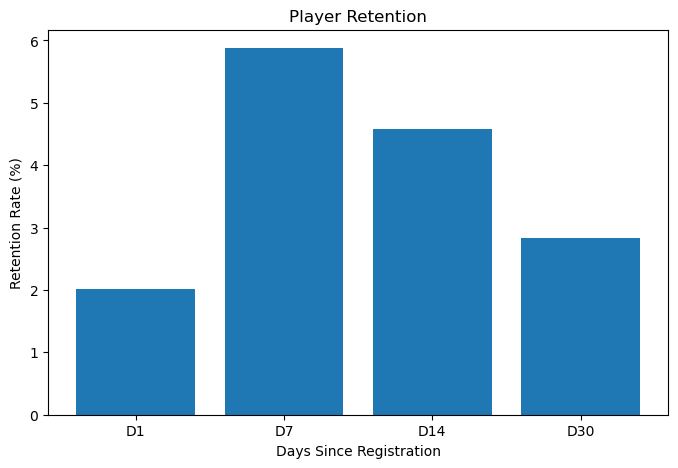

: 

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    retention_overall["day"],
    retention_overall["retention_rate"] * 100
)

plt.title("Player Retention")
plt.xlabel("Days Since Registration")
plt.ylabel("Retention Rate (%)")

plt.show()

La retención de jugadores fue del 2,01 % en el día 1, aumentó al 5,88 % en el día 7 y posteriormente descendió al 4,57 % en el día 14 y al 2,83 % en el día 30. Estas métricas reflejan la retención en días específicos; es decir, un jugador contabilizado en el día 7 no necesariamente había regresado en el día 1. Los resultados sugieren que la actividad de los jugadores alcanza su punto máximo durante la primera semana tras el registro y disminuye gradualmente a lo largo de periodos más extensos.

## 7. A/B Testing

Se analizaron dos grupos de jugadores para evaluar el desempeño de diferentes ofertas promocionales. El grupo A corresponde al control y el grupo B al test. Primero se revisan el tamaño de los grupos y los ingresos totales antes de comparar las principales métricas de monetización

In [ ]:
ab_test.groupby("testgroup").agg(
    users=("user_id", "nunique"),
    total_revenue=("revenue", "sum")
)

,users,total_revenue
testgroup,,
a,202103,5136189
b,202667,5421603


: 

Ambos grupos tienen tamaños similares, con 202,103 usuarios en A y 202,667 en B. El grupo B generó un mayor ingreso total, pero esta diferencia por sí sola no permite determinar qué oferta tuvo mejor desempeño, por lo que se analizarán métricas normalizadas como conversión, ARPU y ARPPU.

### 7.1 Métricas principales del A/B Test

Para comparar el desempeño de ambos grupos se analizaron tres métricas principales de monetización:
- Conversion Rate: porcentaje de usuarios que realizaron al menos un pago (revenue > 0).
- ARPU (Average Revenue Per User): ingreso promedio considerando a todos los usuarios.
- ARPPU (Average Revenue Per Paying User): ingreso promedio considerando únicamente a los usuarios que realizaron algún pago.

In [ ]:
ab_metrics = (
    ab_test.groupby("testgroup")
    .agg(
        users=("user_id", "nunique"),
        paying_users=("revenue", lambda x: (x > 0).sum()),
        total_revenue=("revenue", "sum"),
        arpu=("revenue", "mean")
    )
)

ab_metrics["conversion_rate"] = (
    ab_metrics["paying_users"] / ab_metrics["users"]
)

ab_metrics["arppu"] = (
    ab_metrics["total_revenue"] / ab_metrics["paying_users"]
)

ab_metrics

,users,paying_users,total_revenue,arpu,conversion_rate,arppu
testgroup,,,,,,
a,202103,1928,5136189,25.413720,0.009540,2663.998444
b,202667,1805,5421603,26.751287,0.008906,3003.658172


: 

El grupo B presenta un ARPU aproximadamente 5.3% mayor y un ARPPU aproximadamente 12.7% mayor que el grupo A. Sin embargo, su tasa de conversión es menor (0.891% frente a 0.954%). Por lo tanto, aunque B genera más ingresos promedio, una menor proporción de sus usuarios realiza pagos. Se utilizarán pruebas estadísticas para determinar si estas diferencias son significativas.

### 7.2 Prueba estadística de conversión

Para determinar si la diferencia en la tasa de conversión entre los grupos A y B es estadísticamente significativa, se utiliza una prueba Z para dos proporciones con un nivel de significancia de α = 0.05.

- H₀: las tasas de conversión de A y B son iguales.
- H₁: las tasas de conversión de A y B son diferentes.

In [ ]:
count = ab_metrics["paying_users"].values
nobs = ab_metrics["users"].values

z_stat, p_value = proportions_ztest(count, nobs)

print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.4f}")

Z-statistic: 2.1080
P-value: 0.0350


: 

Como p = 0.035 < 0.05, se rechaza H₀. Existe evidencia estadística de una diferencia en las tasas de conversión entre ambos grupos. El grupo A presenta una conversión de 0.954%, frente a 0.891% en B, por lo que el grupo B muestra una tasa de conversión significativamente menor.

### 7.3 Prueba estadística de ARPU

Para determinar si el ingreso promedio por usuario (ARPU) difiere significativamente entre los grupos A y B, se utiliza Welch's t-test para dos muestras independientes, que no asume igualdad de varianzas. Se utiliza α = 0.05.
- H₀: el ingreso promedio por usuario es igual en A y B.
- H₁: el ingreso promedio por usuario es diferente entre A y B.

In [ ]:
revenue_a = ab_test.loc[
    ab_test["testgroup"] == "a", "revenue"
]

revenue_b = ab_test.loc[
    ab_test["testgroup"] == "b", "revenue"
]

t_stat, p_value = ttest_ind(
    revenue_a,
    revenue_b,
    equal_var=False
)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

T-statistic: -0.6235
P-value: 0.5330


: 

Como p = 0.533 > 0.05, no se rechaza H₀. Aunque el grupo B presenta un ARPU aproximadamente 5.3% mayor (26.75 frente a 25.41), no existe evidencia estadística suficiente para concluir que el ingreso promedio por usuario sea diferente entre ambos grupos.

### 7.4 Prueba estadística de ARPPU
Finalmente, se evalúa si el ingreso promedio entre los usuarios que realizaron al menos un pago (ARPPU) difiere significativamente entre los grupos A y B. Se utiliza nuevamente Welch's t-test con α = 0.05.
- H₀: el ingreso promedio de los usuarios que pagan es igual en A y B.
- H₁: el ingreso promedio de los usuarios que pagan es diferente entre A y B.

In [ ]:
paying_a = ab_test.loc[
    (ab_test["testgroup"] == "a") &
    (ab_test["revenue"] > 0),
    "revenue"
]

paying_b = ab_test.loc[
    (ab_test["testgroup"] == "b") &
    (ab_test["revenue"] > 0),
    "revenue"
]

t_stat_arppu, p_value_arppu = ttest_ind(
    paying_a,
    paying_b,
    equal_var=False
)

print(f"T-statistic: {t_stat_arppu:.4f}")
print(f"P-value: {p_value_arppu:.4f}")

T-statistic: -1.6446
P-value: 0.1002


: 

Como p = 0.100 > 0.05, no se rechaza H₀. Aunque el ARPPU del grupo B es aproximadamente 12.7% mayor que el del grupo A (3003.66 frente a 2664.00), la diferencia no es estadísticamente significativa.

### 7.5 Resumen de resultados del A/B Test
En conjunto, el grupo B presenta mayores valores observados de ARPU (+5.3%) y ARPPU (+12.7%), pero estas diferencias no son estadísticamente significativas. En cambio, B presenta una menor tasa de conversión, y esta diferencia sí es estadísticamente significativa.
Desde una perspectiva de negocio, los resultados no proporcionan evidencia suficiente para justificar reemplazar la oferta A por la oferta B. Aunque B genera mayores ingresos promedio, la mejora no está respaldada estadísticamente y viene acompañada de una reducción significativa en la conversión.

Para visualizar el impacto de B respecto al grupo de control A, se comparan los cambios porcentuales en conversión, ARPU y ARPPU.

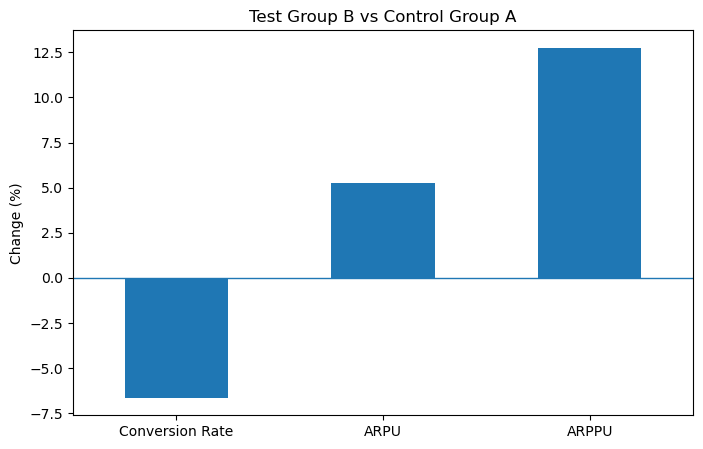

: 

In [ ]:
metric_changes = pd.Series({
    "Conversion Rate": (
        ab_metrics.loc["b", "conversion_rate"]
        / ab_metrics.loc["a", "conversion_rate"] - 1
    ) * 100,

    "ARPU": (
        ab_metrics.loc["b", "arpu"]
        / ab_metrics.loc["a", "arpu"] - 1
    ) * 100,

    "ARPPU": (
        ab_metrics.loc["b", "arppu"]
        / ab_metrics.loc["a", "arppu"] - 1
    ) * 100
})

plt.figure(figsize=(8, 5))
metric_changes.plot(kind="bar")

plt.axhline(0, linewidth=1)
plt.title("Test Group B vs Control Group A")
plt.ylabel("Change (%)")
plt.xlabel("")
plt.xticks(rotation=0)

plt.show()

La visualización muestra el trade-off de la oferta B: aunque presenta mayores ARPU y ARPPU, también reduce la tasa de conversión. Las pruebas estadísticas mostraron que únicamente la reducción en conversión fue estadísticamente significativa.

## Conclusiones
Este análisis permitió evaluar dos aspectos importantes del comportamiento de los jugadores: retención y monetización.
Retención: entre los periodos analizados, D7 presentó la mayor retención de día exacto con 5.88%, seguida de D14 con 4.57%, D30 con 2.83% y D1 con 2.01%. Estos resultados muestran que una parte importante de los jugadores no mantiene actividad frecuente después del registro y sugieren una oportunidad para investigar qué factores impulsan el regreso de los usuarios durante la primera semana.

A/B Testing: el grupo B presentó un ARPU aproximadamente 5.3% mayor y un ARPPU 12.7% mayor que el grupo A. Sin embargo, estas diferencias no fueron estadísticamente significativas. En contraste, la tasa de conversión disminuyó de 0.954% en A a 0.891% en B, y esta diferencia sí fue estadísticamente significativa.

Recomendación: con la evidencia disponible, no se recomienda reemplazar la oferta A por la oferta B. Aunque B muestra mayores ingresos promedio, estas mejoras no cuentan con evidencia estadística suficiente y están acompañadas por una reducción significativa en la proporción de jugadores que realizan pagos.
Como siguiente paso, sería recomendable investigar los factores asociados con la retención durante los primeros días y realizar nuevas pruebas de ofertas promocionales que busquen aumentar los ingresos sin reducir la conversión.